In [ ]:
!pip install roboflow

In [ ]:
import os
import random
import math
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Torchvision
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.models import vgg16, VGG16_Weights

# COCO
from pycocotools.coco import COCO

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches

num_classes = 2

In [ ]:
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv("ROBOFLOW_API_KEY")

In [ ]:
# fetching the dataset
from roboflow import Roboflow

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("aastha-qfrit").project("mango-cqnvg-uxii8")
version = project.version(1)
dataset = version.download("coco")

root = dataset.location
print("Dataset path:", root)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to mango-1 in coco:: 100%|██████████| 457/457 [00:00<00:00, 1387.67it/s]

Dataset path: /content/mango-1


### Data Pipeline

Custom Dataset

In [ ]:
# Define Custom Dataset
class CocoDataset(Dataset):
    def __init__(self, images_dir, annotation_file, transforms=None):
        self.images_dir = images_dir
        self.coco = COCO(annotation_file)
        self.img_ids = list(self.coco.imgs.keys())
        self.transforms = transforms

        self.cat_ids = self.coco.getCatIds()
        self.cat_id_to_label = {cat_id: (i) for i, cat_id in enumerate(self.cat_ids)}

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.images_dir, img_info['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img /= 255.0

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            xmin, ymin, w, h = ann['bbox']
            # Filter out invalid bounding boxes with zero width or height
            if w > 0 and h > 0:
                xmax = xmin + w
                ymax = ymin + h

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(self.cat_id_to_label[ann['category_id']])
                areas.append(ann['area'])
                iscrowd.append(ann.get('iscrowd', 0))

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        areas = torch.tensor(areas, dtype=torch.float32)
        iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        # If no annotations or all annotations were invalid, return None so dataloader can skip it
        if len(boxes) == 0:
          return None, None

        img = torch.tensor(img).permute(2, 0, 1)  # HWC -> CHW

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

In [ ]:
# Transformations
def get_train_transform():
    def _tf(img):
        return img
    return _tf

def get_valid_transform():
    def _tf(img):
        return img
    return _tf

In [ ]:
root = "mango-1"

train_dataset = CocoDataset(
    images_dir="mango-1/train",
    annotation_file="mango-1/train/_annotations.coco.json",
    transforms=get_train_transform(),
)

valid_dataset = CocoDataset(
    images_dir=os.path.join(root, "valid"),
    annotation_file=os.path.join(root, "valid", "_annotations.coco.json"),
    transforms=get_valid_transform(),
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Data Loader

In [ ]:
num_classes = len(train_dataset.cat_ids) + 1  # +1 for background

def collate_fn(batch):
    batch = [b for b in batch if b[0] is not None and b[1] is not None]
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

### Model Architecture Building

MobileNet Model

In [ ]:
# Load faster R-CNN with MobileNet backbone
def get_model_mobilenet(num_classes):
  # load pretrained model
  model = torchvision.models.detection.faster_rcnn.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)

  # get the number of inputs features for the classifier
  in_features = model.roi_heads.box_predictor.cls_score.in_features

  # replace the pre-trained head with a new one - to detect 2 classes and not 80
  model.roi_heads.box_predictior = FastRCNNPredictor(in_features, num_classes)

  return model

In [ ]:
# Initialize the model
model_1 = get_model_mobilenet(num_classes)

VGG16 Model

In [ ]:
# Load Faster R-CNN with VGG16 backbone
def get_model_vgg(num_classes):

    # Load pretrained VGG16
    vgg = vgg16(weights=VGG16_Weights.DEFAULT)

    # Extract last convolution layer
    return_layers = {"29": "0"}  # conv5_3 output
    backbone = IntermediateLayerGetter(
        vgg.features,
        return_layers=return_layers
    )

    # Backbone output channels
    backbone.out_channels = 512

    # Anchor generator (small objects)
    anchor_generator = AnchorGenerator(
        sizes=((8, 16, 32, 64, 128),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # ROI Pooling
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    # Create Faster R-CNN model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    # Fix image resize
    model.transform.min_size = (1024,)
    model.transform.max_size = 1333

    return model

In [ ]:
# Intialize Vgg Model
model_2 = get_model_vgg(2)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 169MB/s]


ResNet50 Model

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

def get_model_resnet(num_classes):

    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    return model

In [ ]:
# Intialize ResNet50 Model
model_3 = get_model_resnet(num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 168MB/s]


### Model Traning

Trainig For MobileNet

In [ ]:
# Traning for Mobilenet
model = model_1
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=5,
                                               gamma=0.1)
num_epochs = 10

In [ ]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        # Skip empty batches
        if len(batch) == 0:
            continue

        images, targets = batch

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    lr_scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 0.5214
Epoch [2/10] Loss: 0.5164
Epoch [3/10] Loss: 0.5106
Epoch [4/10] Loss: 0.5213
Epoch [5/10] Loss: 0.5182
Epoch [6/10] Loss: 0.5057
Epoch [7/10] Loss: 0.5091
Epoch [8/10] Loss: 0.5061
Epoch [9/10] Loss: 0.5102
Epoch [10/10] Loss: 0.5034


In [ ]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "mobilenet_model_final.pth")

Training For VGG16

In [ ]:
# Traning for VGG
model = model_2
# Set device to 'cpu' as a workaround/diagnostic step
device = torch.device('cpu') # Originally: torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=5,
                                               gamma=0.1)
num_epochs = 10

In [ ]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        # Skip empty batches
        if len(batch) == 0:
            continue

        images, targets = batch

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    lr_scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

In [ ]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "vgg_model_final.pth")

Training for ResNet50

In [ ]:
model = model_3
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [ ]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        # Skip empty batches
        if len(batch) == 0:
            continue

        images, targets = batch

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    lr_scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 0.9613
Epoch [2/10] Loss: 0.8073
Epoch [3/10] Loss: 0.7648
Epoch [4/10] Loss: 0.7435
Epoch [5/10] Loss: 0.7097
Epoch [6/10] Loss: 0.6599
Epoch [7/10] Loss: 0.6461
Epoch [8/10] Loss: 0.6399
Epoch [9/10] Loss: 0.6315
Epoch [10/10] Loss: 0.6313


In [ ]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "resnet_model_final.pth")

### Model Evaluation

In [ ]:
# Calculate IoU
def compute_iou(box1, box2):

    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    intersection = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area_box1 + area_box2 - intersection
    return intersection / union if union > 0 else 0.0

In [ ]:
# Calculate Precision and Recall
def calculate_precision_recall(tp, fp, fn):

    precision = tp / (tp + fp + np.finfo(float).eps)
    recall = tp / (tp + fn + np.finfo(float).eps)

    return precision, recall

In [ ]:
# Calculate mAP
def calculate_average_precision(recall, precision):
    recall = np.concatenate(([0], recall, [1]))
    precision = np.concatenate(([0], precision, [0]))
    for i in range(len(precision) - 1, 0, -1):
        precision[i - 1] = max(precision[i - 1], precision[i])
    idx = np.where(recall[1:] != recall[:-1])[0]
    ap = np.sum((recall[idx + 1] - recall[idx]) * precision[idx + 1])

    return ap

In [ ]:
# Final Metrics For Evaluation
def calculate_map(gt_df, pred_df, iou_threshold=0.5):

    unique_classes = gt_df['class'].unique()
    ap_list = []

    total_tp, total_fp, total_fn = 0, 0, 0
    iou_list = []

    for cls in unique_classes:
        gt_cls = gt_df[gt_df['class'] == cls]
        pred_cls = pred_df[pred_df['class'] == cls]

        total_fn += len(gt_cls)

        if pred_cls.empty:
            continue

        pred_cls = pred_cls.sort_values(by='confidence', ascending=False).reset_index(drop=True)

        tp = np.zeros(len(pred_cls))
        fp = np.zeros(len(pred_cls))
        gt_used = {}

        for pred_idx, pred_row in pred_cls.iterrows():
            gt_boxes = gt_cls[gt_cls['image_id'] == pred_row['image_id']]

            best_iou = 0
            best_gt_idx = None

            for gt_idx, gt_row in gt_boxes.iterrows():
                iou = compute_iou(
                    [pred_row['xmin'], pred_row['ymin'], pred_row['xmax'], pred_row['ymax']],
                    [gt_row['xmin'], gt_row['ymin'], gt_row['xmax'], gt_row['ymax']]
                )
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_iou >= iou_threshold and best_gt_idx not in gt_used:
                tp[pred_idx] = 1
                gt_used[best_gt_idx] = True
                iou_list.append(best_iou)
            else:
                fp[pred_idx] = 1

        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)

        recall_curve = tp_cumsum / len(gt_cls)
        precision_curve = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

        ap = calculate_average_precision(recall_curve, precision_curve)
        ap_list.append(ap)

        total_tp += tp.sum()
        total_fp += fp.sum()

    total_fn -= total_tp

    precision, recall = calculate_precision_recall(total_tp, total_fp, total_fn)
    mean_iou = np.mean(iou_list) if len(iou_list) > 0 else 0.0
    mean_ap = np.mean(ap_list) if ap_list else 0.0

    return mean_ap, precision, recall, mean_iou

In [ ]:
# Groundtooth Boxes DataLoader
def build_gt_df(annotation_file):
    coco = COCO(annotation_file)

    cat_id_to_name = {
        cat["id"]: cat["name"]
        for cat in coco.loadCats(coco.getCatIds())
    }

    records = []
    for img_id in coco.getImgIds():
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            xmin, ymin, w, h = ann["bbox"]
            records.append({
                "image_id": img_id,
                "class": cat_id_to_name[ann["category_id"]],
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmin + w,
                "ymax": ymin + h
            })

    return pd.DataFrame(records), cat_id_to_name

In [ ]:
# prediction DataLoader
def build_pred_df(
    model,
    dataloader,
    device,
    cat_id_to_name,
    conf_thresh=0.05
):
    model.eval()
    records = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                img_id = target["image_id"].item()

                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    if score < conf_thresh:
                        continue

                    records.append({
                        "image_id": img_id,
                        "class": cat_id_to_name[label],
                        "confidence": float(score),
                        "xmin": float(box[0]),
                        "ymin": float(box[1]),
                        "xmax": float(box[2]),
                        "ymax": float(box[3]),
                    })

    return pd.DataFrame(records)

In [ ]:
def load_model(model_name, num_classes, weight_path, device):
    if model_name == "mobilenet":
        model = get_model_mobilenet(num_classes)

    # elif model_name == "vgg":
    #     model = get_model_vgg(num_classes)

    elif model_name == "resnet":
        model = get_model_resnet(num_classes)

    else:
        raise ValueError("Invalid model name")

    # Fix: Add weights_only=False to torch.load
    model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=False))
    model.to(device)
    model.eval()

    return model

In [ ]:
def evaluate_model(
    model_name,
    weight_path,
    gt_df,
    dataloader,
    cat_id_to_name,
    num_classes,
    device,
    iou_thresh=0.5
):
    model = load_model(
        model_name,
        num_classes,
        weight_path,
        device
    )

    pred_df = build_pred_df(
        model,
        dataloader,
        device,
        cat_id_to_name
    )

    map50, prec50, rec50, iou50 = calculate_map(gt_df, pred_df, 0.5)

    return {
        "mAP@0.5": map50,
        "Precision@0.5": prec50,
        "Recall@0.5": rec50,
        "Mean IoU@0.5": iou50
        }, pred_df


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build GT once
gt_df, cat_id_to_name = build_gt_df(
    "mango-1/valid/_annotations.coco.json"
)

#Evaluate MobileNet
metrics_mobilenet, _  = evaluate_model(
    model_name="mobilenet",
    weight_path="mobilenet_model_final.pth",
    gt_df=gt_df,
    dataloader=valid_loader,
    cat_id_to_name=cat_id_to_name,
    num_classes=num_classes,
    device=device
)

# # Evaluate VGG
metrics_vgg, _ = evaluate_model(
    model_name="vgg",
    weight_path="vgg_model_final.pth",
    gt_df=gt_df,
    dataloader=valid_loader,
    cat_id_to_name=cat_id_to_name,
    num_classes=num_classes,
    device=device
)

# Evaluate ResNet50
metrics_resnet, _ = evaluate_model(
    model_name="resnet",
    weight_path="resnet_model_final.pth",
    gt_df=gt_df,
    dataloader=valid_loader,
    cat_id_to_name=cat_id_to_name,
    num_classes=num_classes,
    device=device
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [ ]:
# results
print(
    f"MobileNet\n"
    f"Precision = {metrics_mobilenet['Precision@0.5']:.4f} \n"
    f"Recall = {metrics_mobilenet['Recall@0.5']:.4f} \n"
    f"IoU = {metrics_mobilenet['Mean IoU@0.5']:.4f} \n"
    f"mAP@0.5 = {metrics_mobilenet['mAP@0.5']:.4f} \n"
)

print(
    f"\n VGG16\n"
    f"Precision = {metrics_vgg['Precision@0.5']:.4f} \n"
    f"Recall = {metrics_vgg['Recall@0.5']:.4f} \n"
    f"IoU = {metrics_vgg['Mean IoU@0.5']:.4f} \n"
    f"mAP@0.5 = {metrics_vgg['mAP@0.5']:.4f} \n"
)

print(
    f"\n ResNet50\n"
    f"Precision = {metrics_resnet['Precision@0.5']:.4f} \n"
    f"Recall = {metrics_resnet['Recall@0.5']:.4f} \n"
    f"IoU = {metrics_resnet['Mean IoU@0.5']:.4f} \n"
    f"mAP@0.5 = {metrics_resnet['mAP@0.5']:.4f} \n"
)

MobileNet
Precision = 0.1234 
Recall = 0.4521 
IoU = 0.6294 
mAP@0.5 = 0.1912 


 ResNet50
Precision = 0.3691 
Recall = 0.7470 
IoU = 0.6840 
mAP@0.5 = 0.6212 



### Model Comparison

In [ ]:
models = ["mobilenet", "vgg", "resnet"]

precision = [metrics_mobilenet['Precision@0.5'], metrics_mobilenet['Recall@0.5']]
recall    = [metrics_mobilenet['Recall@0.5'], metrics_vgg['Recall@0.5']]
iou       = [metrics_mobilenet['Mean IoU@0.5'], metrics_vgg['Mean IoU@0.5']]
map50     = [metrics_mobilenet['mAP@0.5'], metrics_vgg['mAP@0.5']]

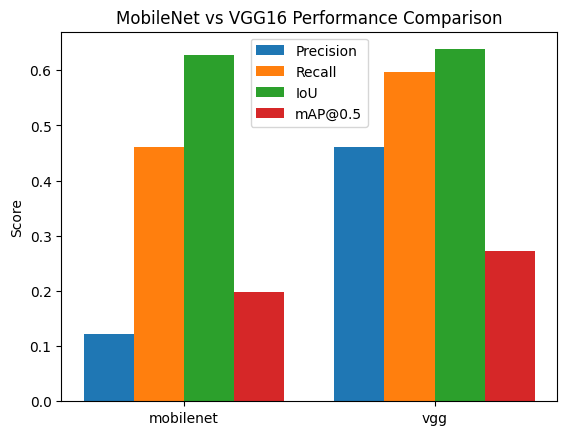

In [ ]:
# Camparison Plot
x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, precision, width, label="Precision")
plt.bar(x - 0.5*width, recall,    width, label="Recall")
plt.bar(x + 0.5*width, iou,       width, label="IoU")
plt.bar(x + 1.5*width, map50,     width, label="mAP@0.5")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("MobileNet vs VGG16 Performance Comparison")
plt.legend()
plt.show()

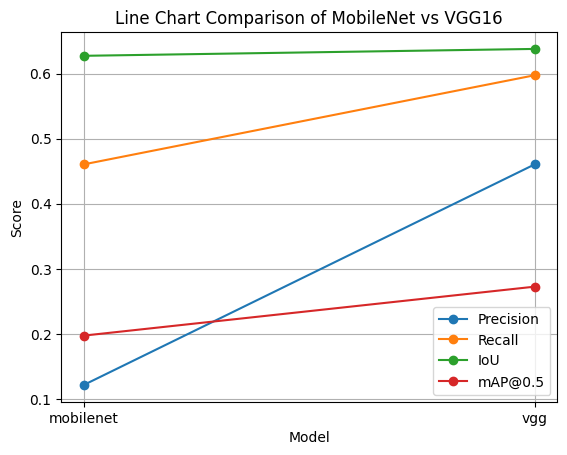

In [ ]:
plt.figure()

plt.plot(models, precision, marker='o', label="Precision")
plt.plot(models, recall,    marker='o', label="Recall")
plt.plot(models, iou,       marker='o', label="IoU")
plt.plot(models, map50,     marker='o', label="mAP@0.5")

plt.title("Line Chart Comparison of MobileNet vs VGG16")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

### Visual Representation

In [ ]:
def draw_boxes(ax, boxes, color="green"):
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=0.5,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

In [ ]:
def visualize_gt_vs_prediction(
    model_name,
    weight_path,
    dataset,
    img_index,
    num_classes,
    device,
    score_thresh=0.3
):
    model = load_model(
        model_name=model_name,
        num_classes=num_classes,
        weight_path=weight_path,
        device=device
    )

    img, target = dataset[img_index]
    img_np = img.permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model([img.to(device)])[0]

    keep = output["scores"] >= score_thresh
    pred_boxes = output["boxes"][keep].cpu().numpy()

    gt_boxes = target["boxes"].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Ground Truth
    axes[0].imshow(img_np)
    draw_boxes(axes[0], gt_boxes, color="blue")
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    # Predictions
    axes[1].imshow(img_np)
    draw_boxes(axes[1], pred_boxes, color="red")
    axes[1].set_title(f"{model_name.upper()} Predictions")
    axes[1].axis("off")

    plt.show()

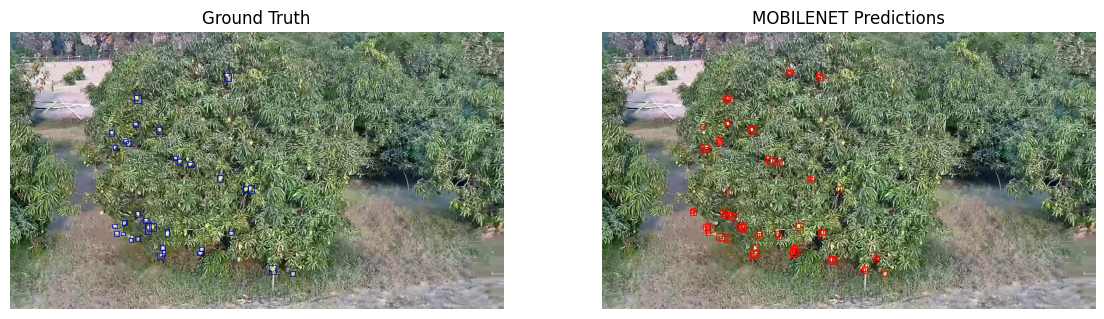

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

visualize_gt_vs_prediction(
    model_name="mobilenet",
    weight_path="mobilenet_model_final.pth",
    dataset=valid_dataset,
    img_index=5,
    num_classes=2,
    device=device,
    score_thresh=0.3
)

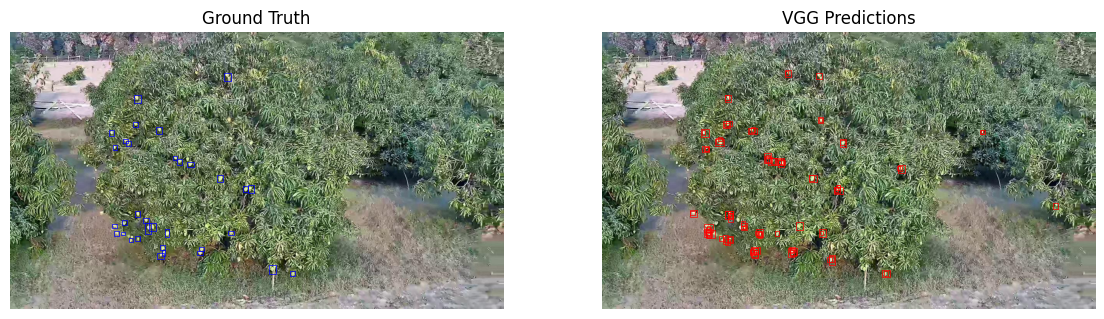

In [ ]:
visualize_gt_vs_prediction(
    model_name="vgg",
    weight_path="vgg_model_final.pth",
    dataset=valid_dataset,
    img_index=5,
    num_classes=2,
    device=device,
    score_thresh=0.3
)